# Distractor sex conditions pilot task results

In [1]:
import pickle
import numpy as np 
import re 
from pathlib import Path
import pandas as pd
import json
import pickle

%matplotlib inline 

import matplotlib.pyplot as plt 
import seaborn as sns
# from matplotlib.ticker import FormatStrFormatter



### Get model results

In [2]:
## import class maps
import pickle
## load WSN vocab mapping 
word_and_speaker_encodings = pickle.load( open( "/om2/user/imgriff/projects/Auditory-Attention/word_and_speaker_encodings_jsinv3.pckl", "rb" )) 
wsn_word_2_class = word_and_speaker_encodings['word_to_idx']
wsn_class_2_word = word_and_speaker_encodings['word_idx_to_word']

cv_word_2_class = pickle.load( open("/om2/user/imgriff/datasets/commonvoice_9/en/cv_800_word_label_to_int_dict.pkl", "rb" )) 
cv_class_2_word = {v:k for k,v in cv_word_2_class.items()}


In [3]:
# results_dirs

In [4]:
parent_path = Path('/om2/user/imgriff/projects/torch_2_aud_attn/swc_distractor_sex/')
results_dirs = list(parent_path.rglob(f"*/*.csv"))
print(len(results_dirs))

meta_df = pd.read_pickle('/om/user/imgriff/datasets/human_distractor_sex_2024/full_expmt_stim_manifest.pdpkl')

dfs = []

for result_csv in results_dirs:
    df = pd.read_csv(result_csv)
    df['sex_cond'] = "same" if 'same' in result_csv.stem else "different" if 'different' in result_csv.stem else 'clean'
    df['model'] = result_csv.parent.stem
    df['target_word'] = df['true_word_int'].replace(cv_class_2_word)
    df['pred_word'] = df['pred_word_int'].replace(cv_class_2_word)
    if 'SILENCE' in result_csv.stem:
        df['snr'] = 'inf'
    else:
        df['snr'] = int(re.search('(-?\d+)dB', result_csv.stem).group(0).strip('dB'))
    dfs.append(df)

model_results = pd.concat(dfs, axis=0, ignore_index=True)



11


In [5]:
# model_results.head()

### Load human data

In [6]:
path_to_human_data = Path('/mindhive/mcdermott/www/imgriff/msjspsych/')
# !ls {path_to_human_data}
# full paths to .json files 
human_fnames = list(path_to_human_data.glob("cocktail_party_distractor_sex/data/*.json"))

# import vocab dict for matching audio & responses 
# word_and_speaker_encodings = pickle.load( open("/om2/user/imgriff/projects/Auditory-Attention/word_and_speaker_encodings_jsinv3.pckl", "rb" )) 
# # ix_to_word_map = {v:k for k,v in class_map.items()}
# class_map = word_and_speaker_encodings['word_idx_to_word']
len(human_fnames)


106

In [7]:
# human_fnames

In [8]:
## Get all subject data into one df for analysis

def get_part_df(fname):
    part_data = json.load(open(fname, 'r'))
    # print(f"{fname.stem} success {part_data[0]['success']}")
    part_df = pd.DataFrame.from_records(part_data)
    ## Forward fill stim presentation entry to word response entry
    responses = part_df.loc[part_df.trial_type.isin(['audio-keyboard-response','dictionary-text']), ['trial_index', 'stimulus']]
    responses = responses.ffill()
    part_df.loc[part_df['trial_index'].isin(responses["trial_index"].values), 'stimulus'] = responses.stimulus
    return part_df

dfs = []
for fname in human_fnames:
    try:
        dfs.append(get_part_df(fname))
    except Exception as e:
        print(e)
        print(fname)
    
# results_df = pd.concat([get_part_df(fname) for fname in human_fnames], axis=0, ignore_index=True)
results_df = pd.concat(dfs)
print(results_df.id_subject.nunique())
## Filter for those who passed headphone check 
results_df = results_df[results_df.hc_passed == True]
print(results_df.id_subject.nunique())


## Add snr and condition names as columns - unpack from file code in file names 

import re
### Get condition map
with open('/om/user/imgriff/datasets/human_distractor_sex_2024/human_distractor_sex_cond_map.pkl', 'rb') as f:
    stim_cond_map = pickle.load(f)

stim_cond_map = {f"condition_{k:02}": v for k,v in stim_cond_map.items()}

## Map wav str to stim_type using condition dict
def get_stim_snr_and_cond(stim_str, stim_cond_map=stim_cond_map):
    cond, snr = None,  None 
    if isinstance(stim_str, str) and not stim_str.startswith('<'):
        # print(stim_str)
        cond_str = re.search("condition_(-?\d+)", stim_str)
        if cond_str:
            cond_str = cond_str.group(0)
            cond, snr = stim_cond_map[cond_str]
            cond = cond.split('_')[0]
        elif 'catch' in stim_str:
            snr = 'inf'
            cond = 'catch_trial'
    return cond, snr

# add as columns 
results_df['sex_cond'], results_df['snr'] = zip(*results_df['stimulus'].apply(get_stim_snr_and_cond))
results_df.loc[results_df['sex_cond'] == 'SILENCE', 'sex_cond'] = 'clean'
# cut down df to only have trial answers (remove other meta data)
expmnt_trial_str = "dictionary-text"
trial_results = results_df[results_df.trial_type == expmnt_trial_str]


# # screen based on completion 
total_trials = 122 
full_run_subjects = [subj_id for subj_id, did_all_trials in (trial_results.groupby('id_subject').sex_cond.count() == total_trials).items() if did_all_trials == True]
trial_results = trial_results[trial_results.id_subject.isin(full_run_subjects)]

# # Add accuracy 
trial_results['accuracy'] = (trial_results['response'] == trial_results['correct_response']).astype('int')


Unterminated string starting at: line 1 column 59812 (char 59811)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_distractor_sex/data/subj_63052f20afc39e87110eb83e.json
Expecting ',' delimiter: line 1 column 119653 (char 119652)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_distractor_sex/data/subj_60d0709ffc9b494cf65a266c.json
Unterminated string starting at: line 1 column 155420 (char 155419)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_distractor_sex/data/subj_5b2890f10ec82d0001d24b61.json
Unterminated string starting at: line 1 column 59790 (char 59789)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_distractor_sex/data/subj_65b3dc2f924ee9deee8b40b9.json
Unterminated string starting at: line 1 column 11999 (char 11998)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_distractor_sex/data/subj_5ec6d054e1f1a71078cfbcda.json
101
86


In [9]:
trial_results['accuracy'] = (trial_results['response_str'] == trial_results['correct_response']).astype('int')
catch_trial_particiapnt_performance = trial_results[trial_results.sex_cond == 'catch_trial'].groupby('id_subject').accuracy.mean()

print("N total participants ", len(catch_trial_particiapnt_performance))
good_participants = catch_trial_particiapnt_performance[catch_trial_particiapnt_performance >= 10/12].index
print("N good participants ", len(good_participants))

good_results = trial_results[trial_results.id_subject.isin(good_participants)]
analysis_df = good_results[(~good_results.sex_cond.isnull()) & (~good_results.response.isna())]
# analysis_df.groupby('id_subject').sex_cond.count()

N total participants  73
N good participants  66


#### Add meta to participant df 


In [10]:
analysis_df['trial_int'] = analysis_df.stimulus.apply(lambda x: int(x.split('/')[-1].split('.')[0]))
analysis_df['condition_dir'] = analysis_df.stimulus.apply(lambda x: x.split('/')[1])

In [11]:
### Look at 1 talker sex conditions

manifests = pd.read_pickle('/om/user/imgriff/datasets/human_distractor_sex_2024/full_expmt_stim_manifest.pdpkl')

## Will add columns 'base_str', 'target_gender', 'target_f0', 'distractor_f0', 'distractor_gender' from manifests to trial_results where trial_results.stimulus == manifests.base_str

analysis_df = pd.merge(analysis_df,
                        manifests[['condition_dir', 'word', 'gender', 'distractor_gender', 'distractor_word', 'target_transcripts', 'distractor_transcripts']],
                                    left_on=['condition_dir', 'correct_response'], right_on=['condition_dir', 'word'], how='left')
analysis_df['confusions'] = (analysis_df.response == analysis_df.distractor_word).astype('int')

# add adjusted accuracy and confusions 
pred_words = analysis_df.response.values
target_words = analysis_df.correct_response.values
target_transcripts = analysis_df.target_transcripts.values
distractor_transcripts = analysis_df.distractor_transcripts.values
distractor_words = analysis_df.distractor_word.values


adjusted_acc = np.array([int(pred_word in target_transcript or pred_word == target_word)
                            if not (isinstance(target_transcript, float) and target_word) else np.nan
                             for pred_word, target_word, target_transcript in zip(pred_words, target_words, target_transcripts)
                              ])

adjusted_confs = np.array([int(pred_word in distractor_transcript or pred_word == distractor_word)
                            if not (isinstance(distractor_transcript, float) and distractor_word) else np.nan
                             for pred_word, distractor_word, distractor_transcript in zip(pred_words, distractor_words, distractor_transcripts)
                              ])

analysis_df['adjusted_accuracy'] = adjusted_acc
analysis_df['adjusted_confusions'] = adjusted_confs

# analysis_df['sex_cond'] = analysis_df.apply(lambda row: 'Same sex distractor' if row['gender'] == row['distractor_gender'] else 'Different sex distractor', axis=1)
# analysis_df.loc[analysis_df.snr == 'sex_cond'] 

In [12]:
# get trial data excluding catch trials 
analysis_df = analysis_df[analysis_df.catch_trial == 0]

part_summary_df = (analysis_df.groupby(["snr", 'id_subject', 'sex_cond'])
                     .agg({
                            # 'correct':['mean', 'count'],
                            # 'confusions':['mean'],
                            'adjusted_accuracy':['mean', 'count'],
                            'adjusted_confusions':['mean']
                            })
                     .reset_index())

part_summary_df['snr'] = part_summary_df['snr'].replace(np.inf, 6)
part_summary_df['snr'] =  part_summary_df['snr'].replace("inf", 6)
part_summary_df['snr'] = part_summary_df['snr'].astype('int')
# flatten multiindex 
part_summary_df.columns = ['_'.join(col).strip() for col in part_summary_df.columns.values]
# remove trailing underscore
part_summary_df.columns = [col[:-1] if col.endswith('_') else col for col in part_summary_df.columns.values]

# just call adjusted measures the name of the measure 
part_summary_df.rename(columns={'adjusted_accuracy_mean': 'accuracy',  "adjusted_accuracy_count": 'count', 'adjusted_confusions_mean': "confusions"}, inplace=True)


#### Add meta to model

In [13]:
rev_cond_map = {}

for dir_string, (cond, snr) in stim_cond_map.items():
    if cond == 'SILENCE':
        rev_cond_map[f"clean {snr}"] = dir_string
    else:
        rev_cond_map[f"{cond} {snr}"] = dir_string

# rev_cond_map


In [14]:
model_results['condition_dir'] = model_results[['sex_cond', 'snr']].apply(lambda x: rev_cond_map[f"{x.sex_cond} {x.snr}"], axis=1)

In [15]:
model_results.columns

Index(['pred_word_int', 'true_word_int', 'accuracy', 'sex_cond', 'model',
       'target_word', 'pred_word', 'snr', 'condition_dir'],
      dtype='object')

In [16]:
## Will add columns 'base_str', 'target_gender', 'target_f0', 'distractor_f0', 'distractor_gender' from manifests to trial_results where trial_results.stimulus == manifests.base_str

model_results = pd.merge(model_results,
                        manifests[['condition_dir', 'word', 'gender', 'distractor_gender', 'distractor_word', 'target_transcripts', 'distractor_transcripts']],
                                    left_on=['condition_dir', 'target_word'], right_on=['condition_dir', 'word'], how='left')
model_results['confusions'] = (model_results.pred_word == model_results.distractor_word).astype('int')

# add adjusted accuracy and confusions 
pred_words = model_results.pred_word.values
target_words = model_results.target_word.values
target_transcripts = model_results.target_transcripts.values
distractor_transcripts = model_results.distractor_transcripts.values
distractor_words = model_results.distractor_word.values


adjusted_acc = np.array([int(pred_word in target_transcript or pred_word == target_word)
                            if not (isinstance(target_transcript, float) and target_word) else np.nan
                             for pred_word, target_word, target_transcript in zip(pred_words, target_words, target_transcripts)
                              ])

adjusted_confs = np.array([int(pred_word in distractor_transcript or pred_word == distractor_word)
                            if not (isinstance(distractor_transcript, float) and distractor_word) else np.nan
                             for pred_word, distractor_word, distractor_transcript in zip(pred_words, distractor_words, distractor_transcripts)
                              ])

model_results['accuracy'] = adjusted_acc
model_results['confusions'] = adjusted_confs

In [17]:
part_summary_df['group'] = 'Human'
model_results['group'] = model_results['model']
combined_df = pd.concat([model_results, part_summary_df], axis=0, ignore_index=True)

## Line plots

(0.0, 1.0)

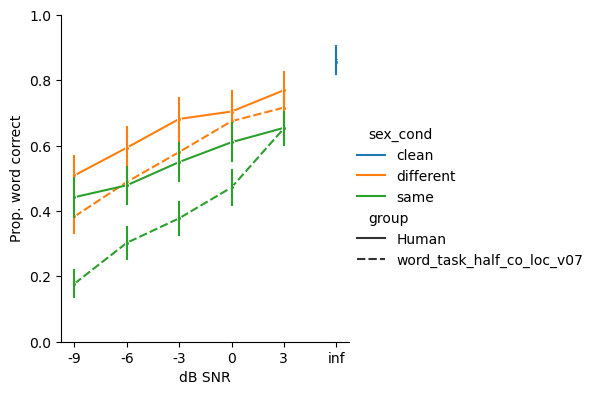

In [18]:
# cmap = sns.color_palette("gnuplot2", n_colors=3)

# palette = {lang:cmap[ix] for ix, lang in enumerate(['dutch', 'mandarin', 'english'])}
# palette['clean'] = 'k'

to_plot = combined_df.copy()
to_plot.loc[to_plot.snr == 'inf', 'snr'] = 6

g = sns.relplot(data=to_plot, x='snr', y='accuracy', # hue='gender_cond',
                # col_wrap=3,
                # hue='Distractor Sex', #
                # col='sex_cond',
                style='group', style_order = ['Human', 'word_task_half_co_loc_v07'],
                hue='sex_cond',
                kind='line', marker='.',
                # color='k',
                # palette=palette,
                height=4, aspect=1,
                err_style='bars', 
                errorbar=('se', 2),)

# set labels 
g.set_axis_labels("dB SNR", "Prop. word correct")
g.set_titles("{col_name}")

# add xtick labels 
x_tick_locs = sorted(part_summary_df.snr.unique())
x_tick_labels = [str(x) for x in x_tick_locs]
x_tick_labels[-1] = 'inf'
for ax in g.axes.flat:
    labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(ticks=x_tick_locs) # set new labels
    ax.set_xticklabels(labels=x_tick_labels)

# g.ax.set_xticks(ticks=results.snr.unique())
# g.set_xticklabels(results.snr.unique())
# plt.title('English targets \nunfamiliar language distractor', y=1.05)
plt.ylim(0,1)